<a href="https://colab.research.google.com/github/maizoh/Project_Shinshu/blob/main/Project_Shinshu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
pd.set_option('display.max_rows', None)
df=pd.read_csv("/content/Medical_Data/MedicalReportPubH_2024.csv",encoding="shift_jis")
df=pd.DataFrame(df)
df_selected=df.iloc[:,[3,5,12,14,33,36,38,45,58,59,60,62,64,66,69]]
df_selected.to_pickle("/content/Medical_Data/df_selected_2024.pickle")

In [3]:
df = pd.read_pickle("/content/Medical_Data/df_selected_2024.pickle")
df.to_csv("/content/Medical_Data/df_test_2024.csv", index=False)

In [4]:
df = pd.read_pickle("/content/Medical_Data/df_selected_2024.pickle")
df_med=df[df["概要"]=="薬剤"]
df_med["発生時間帯"].value_counts()

,count
発生時間帯,
8:00〜9:59,851
10:00〜11:59,715
12:00〜13:59,612
16:00〜17:59,578
14:00〜15:59,562
18:00〜19:59,483
20:00〜21:59,387
6:00〜7:59,261
22:00〜23:59,179


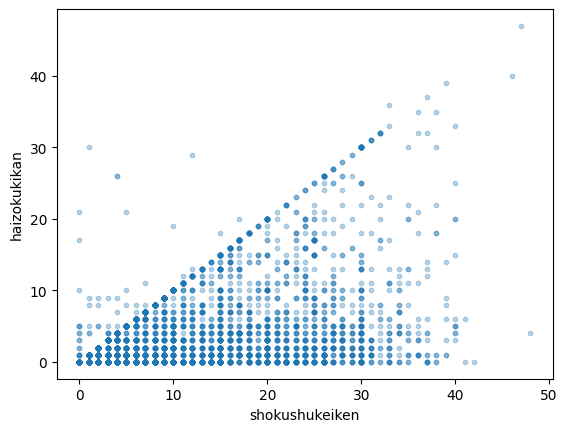

<Figure size 600x100 with 0 Axes>

In [5]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots()

plt.figure(figsize=(6,1))

ax.set_xlabel("shokushukeiken")
ax.set_ylabel("haizokukikan")

df["当事者職種経験（年数）_1"]=df["当事者職種経験（年数）_1"].astype(str).str.replace("年","").astype(int)
df['当事者部署配属期間（年数）_1']=df['当事者部署配属期間（年数）_1'].astype(str).str.replace("年","").astype(int)
x=df["当事者職種経験（年数）_1"]
y=df['当事者部署配属期間（年数）_1']

ax.scatter(x,y,s=10,alpha=0.3)

plt.show()

y=xは配属機関が１か所だけってことだから、多くなるのは必然？
y=x越すはずないのに越してるやつらいるので洗浄する

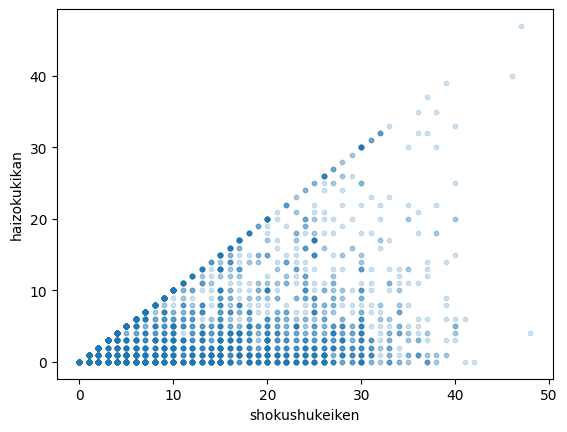

<Figure size 600x100 with 0 Axes>

In [6]:
df_clean=df[df['当事者職種経験（年数）_1']>=df['当事者部署配属期間（年数）_1']].copy()
fig,ax=plt.subplots()

plt.figure(figsize=(6,1))

ax.set_xlabel("shokushukeiken")
ax.set_ylabel("haizokukikan")

df_clean["当事者職種経験（年数）_1"]=df_clean["当事者職種経験（年数）_1"].astype(str).str.replace("年","").astype(int)
df_clean['当事者部署配属期間（年数）_1']=df_clean['当事者部署配属期間（年数）_1'].astype(str).str.replace("年","").astype(int)
x=df_clean["当事者職種経験（年数）_1"]
y=df_clean['当事者部署配属期間（年数）_1']

ax.scatter(x,y,s=10,alpha=0.2)

plt.show()

20から30年あたりが顕著だが、こんだけのベテランでも配属期間が短いほどミスしやすくなっている感じがある。(下のほうが濃いことから)

当事者部署配属期間（年数）_1
0     23.592493
2     11.796247
1     11.528150
10     9.651475
3      9.115282
5      6.568365
4      5.227882
13     3.619303
6      3.217158
11     3.083110
7      3.083110
8      2.949062
12     2.278820
15     2.010724
9      1.340483
14     0.938338
Name: proportion, dtype: float64


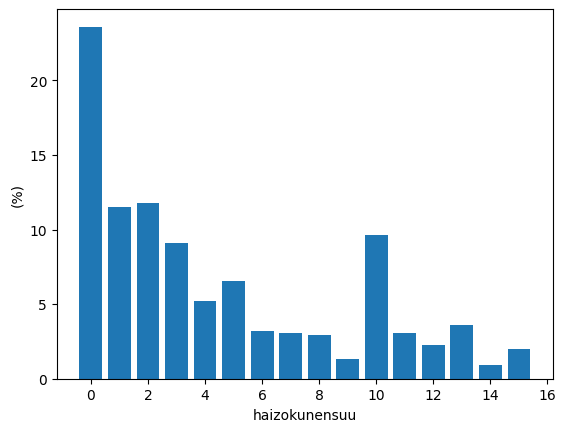

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# 1. データ加工・フィルタリング
df_clean["当事者職種経験（年数）_1"] = df_clean["当事者職種経験（年数）_1"].astype(str).str.replace("年","").astype(int)
df_clean['当事者部署配属期間（年数）_1'] = df_clean['当事者部署配属期間（年数）_1'].astype(str).str.replace("年","").astype(int)

filtered_df = df_clean[(df_clean["当事者職種経験（年数）_1"] >= 10) & (df_clean["当事者職種経験（年数）_1"] <= 15)]

# 2. 比率の集計（ここで比率データを作る）
assignment_ratio = filtered_df["当事者部署配属期間（年数）_1"].value_counts(normalize=True) * 100

# 3. グラフ描画の設定
fig, ax = plt.subplots()

# x軸には「年数（index）」、y軸には「比率（値）」を渡す
x = assignment_ratio.index
y = assignment_ratio.values

ax.bar(x, y)


ax.set_xlabel("haizokunensuu")
ax.set_ylabel("(%)")


print(assignment_ratio)
plt.show()

In [30]:
assignment_ratio.head()

,proportion
当事者部署配属期間（年数）_1,
0,23.592493
2,11.796247
1,11.528150
10,9.651475
3,9.115282


当事者部署配属期間（年数）_1
0     15.109344
1     14.512922
2     10.139165
3      9.940358
4      9.343936
5      5.765408
17     3.777336
7      3.379722
10     3.379722
20     3.180915
16     3.180915
8      2.385686
15     2.385686
6      2.385686
14     2.186879
18     2.186879
9      1.988072
11     1.391650
13     1.391650
19     0.994036
12     0.994036
Name: proportion, dtype: float64


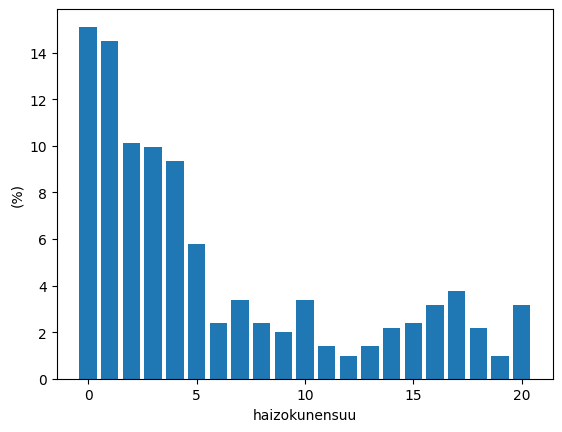

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# 1. データ加工・フィルタリング
df_clean["当事者職種経験（年数）_1"] = df_clean["当事者職種経験（年数）_1"].astype(str).str.replace("年","").astype(int)
df_clean['当事者部署配属期間（年数）_1'] = df_clean['当事者部署配属期間（年数）_1'].astype(str).str.replace("年","").astype(int)

filtered_df = df_clean[(df_clean["当事者職種経験（年数）_1"] >= 16) & (df_clean["当事者職種経験（年数）_1"] <= 20)]

# 2. 比率の集計（ここで比率データを作る）
assignment_ratio = filtered_df["当事者部署配属期間（年数）_1"].value_counts(normalize=True) * 100

# 3. グラフ描画の設定
fig, ax = plt.subplots()

# x軸には「年数（index）」、y軸には「比率（値）」を渡す
x = assignment_ratio.index
y = assignment_ratio.values

ax.bar(x, y)


ax.set_xlabel("haizokunensuu")
ax.set_ylabel("(%)")


print(assignment_ratio)
plt.show()

当事者部署配属期間（年数）_1
0     19.512195
1     14.390244
2      9.512195
3      7.073171
5      5.853659
4      5.365854
7      4.146341
9      3.902439
6      3.414634
17     3.414634
11     2.439024
15     2.195122
13     1.951220
10     1.951220
14     1.707317
20     1.707317
16     1.707317
12     1.707317
22     1.463415
18     1.463415
8      1.219512
19     0.975610
21     0.975610
24     0.731707
25     0.731707
23     0.487805
Name: proportion, dtype: float64


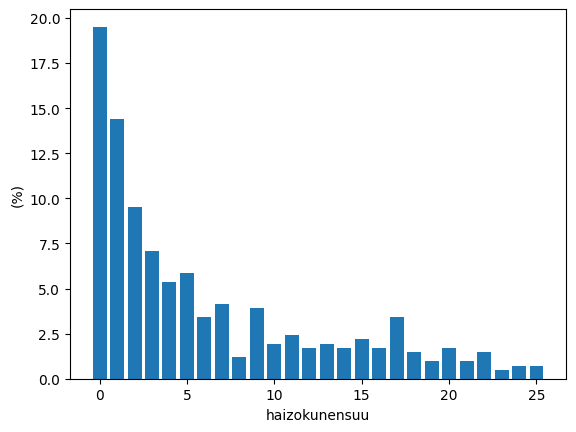

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# 1. データ加工・フィルタリング
df_clean["当事者職種経験（年数）_1"] = df_clean["当事者職種経験（年数）_1"].astype(str).str.replace("年","").astype(int)
df_clean['当事者部署配属期間（年数）_1'] = df_clean['当事者部署配属期間（年数）_1'].astype(str).str.replace("年","").astype(int)

filtered_df = df_clean[(df_clean["当事者職種経験（年数）_1"] >= 21) & (df_clean["当事者職種経験（年数）_1"] <= 25)]

# 2. 比率の集計（ここで比率データを作る）
assignment_ratio = filtered_df["当事者部署配属期間（年数）_1"].value_counts(normalize=True) * 100

# 3. グラフ描画の設定
fig, ax = plt.subplots()

# x軸には「年数（index）」、y軸には「比率（値）」を渡す
x = assignment_ratio.index
y = assignment_ratio.values

ax.bar(x, y)


ax.set_xlabel("haizokunensuu")
ax.set_ylabel("(%)")


print(assignment_ratio)
plt.show()

当事者部署配属期間（年数）_1
0     14.689266
1     13.559322
2     10.169492
3      9.604520
4      8.474576
5      7.344633
30     3.954802
10     3.672316
6      3.672316
26     3.389831
8      2.542373
9      2.259887
7      2.259887
13     1.977401
25     1.694915
11     1.412429
15     1.412429
27     1.129944
16     1.129944
20     0.847458
18     0.847458
12     0.564972
14     0.564972
29     0.564972
22     0.564972
28     0.564972
24     0.564972
19     0.282486
21     0.282486
Name: proportion, dtype: float64


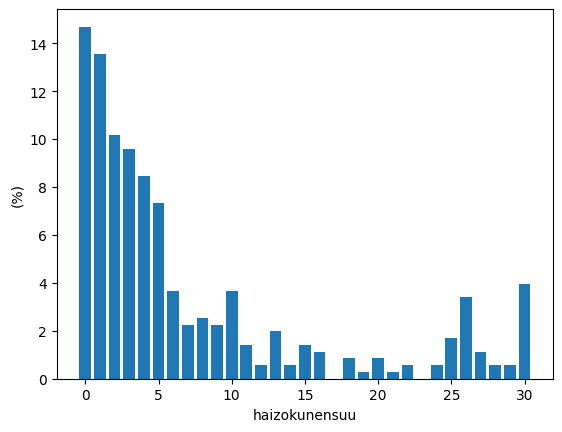

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# 1. データ加工・フィルタリング
df_clean["当事者職種経験（年数）_1"] = df_clean["当事者職種経験（年数）_1"].astype(str).str.replace("年","").astype(int)
df_clean['当事者部署配属期間（年数）_1'] = df_clean['当事者部署配属期間（年数）_1'].astype(str).str.replace("年","").astype(int)

filtered_df = df_clean[(df_clean["当事者職種経験（年数）_1"] >= 26) & (df_clean["当事者職種経験（年数）_1"] <= 30)]

# 2. 比率の集計（ここで比率データを作る）
assignment_ratio = filtered_df["当事者部署配属期間（年数）_1"].value_counts(normalize=True) * 100

# 3. グラフ描画の設定
fig, ax = plt.subplots()

# x軸には「年数（index）」、y軸には「比率（値）」を渡す
x = assignment_ratio.index
y = assignment_ratio.values

ax.bar(x, y)


ax.set_xlabel("haizokunensuu")
ax.set_ylabel("(%)")


print(assignment_ratio)
plt.show()

当事者部署配属期間（年数）_1
0     12.0
1     12.0
2      9.6
3      8.8
4      8.0
5      5.6
7      4.8
8      4.8
11     4.8
32     4.0
13     4.0
31     3.2
6      3.2
10     3.2
17     2.4
20     2.4
23     1.6
22     1.6
16     0.8
12     0.8
30     0.8
33     0.8
18     0.8
Name: proportion, dtype: float64


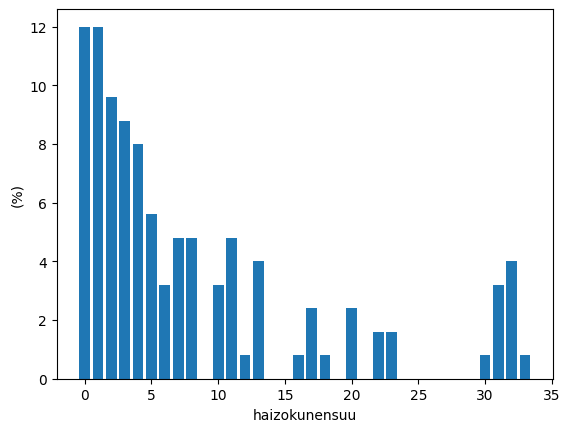

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# 1. データ加工・フィルタリング
df_clean["当事者職種経験（年数）_1"] = df_clean["当事者職種経験（年数）_1"].astype(str).str.replace("年","").astype(int)
df_clean['当事者部署配属期間（年数）_1'] = df_clean['当事者部署配属期間（年数）_1'].astype(str).str.replace("年","").astype(int)

filtered_df = df_clean[(df_clean["当事者職種経験（年数）_1"] >= 31) & (df_clean["当事者職種経験（年数）_1"] <= 35)]

# 2. 比率の集計（ここで比率データを作る）
assignment_ratio = filtered_df["当事者部署配属期間（年数）_1"].value_counts(normalize=True) * 100

# 3. グラフ描画の設定
fig, ax = plt.subplots()

# x軸には「年数（index）」、y軸には「比率（値）」を渡す
x = assignment_ratio.index
y = assignment_ratio.values

ax.bar(x, y)


ax.set_xlabel("haizokunensuu")
ax.set_ylabel("(%)")


print(assignment_ratio)
plt.show()

当事者部署配属期間（年数）_1
1     16.417910
0     13.432836
3      8.955224
4      8.955224
6      7.462687
5      5.970149
18     4.477612
35     2.985075
32     2.985075
20     2.985075
14     2.985075
47     1.492537
15     1.492537
13     1.492537
25     1.492537
22     1.492537
33     1.492537
21     1.492537
9      1.492537
11     1.492537
39     1.492537
37     1.492537
30     1.492537
8      1.492537
12     1.492537
40     1.492537
Name: proportion, dtype: float64


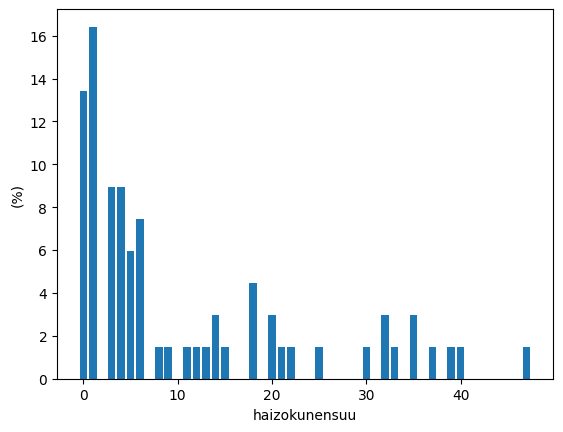

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# 1. データ加工・フィルタリング
df_clean["当事者職種経験（年数）_1"] = df_clean["当事者職種経験（年数）_1"].astype(str).str.replace("年","").astype(int)
df_clean['当事者部署配属期間（年数）_1'] = df_clean['当事者部署配属期間（年数）_1'].astype(str).str.replace("年","").astype(int)

filtered_df = df_clean[(df_clean["当事者職種経験（年数）_1"] >= 36) ]

# 2. 比率の集計（ここで比率データを作る）
assignment_ratio = filtered_df["当事者部署配属期間（年数）_1"].value_counts(normalize=True) * 100

# 3. グラフ描画の設定
fig, ax = plt.subplots()

# x軸には「年数（index）」、y軸には「比率（値）」を渡す
x = assignment_ratio.index
y = assignment_ratio.values

ax.bar(x, y)


ax.set_xlabel("haizokunensuu")
ax.set_ylabel("(%)")


print(assignment_ratio)
plt.show()